File ML ditemukan:
C:\Users\rizki\OneDrive\Documents\SEMESTER 6 (Magang Studi Independen)\PROJEK\OTDR\machine learning\reports\ml_model_comparison_rf_svm_lr_voting.csv

File CNN-LSTM ditemukan:
C:\Users\rizki\OneDrive\Documents\SEMESTER 6 (Magang Studi Independen)\PROJEK\OTDR\reports\cnn_lstm_single_input_evaluation.csv

Kolom file ML:
['model_name', 'accuracy', 'precision_macro', 'recall_macro', 'f1_macro', 'roc_auc_macro_ovr', 'training_time_sec', 'testing_delay_sec']

Kolom file CNN-LSTM:
['model_name', 'accuracy', 'precision_macro', 'recall_macro', 'f1_macro', 'roc_auc_macro', 'training_time_sec', 'testing_delay_sec']

Tabel gabungan final:
             model_name  accuracy  precision_macro  recall_macro  f1_macro  \
0   Logistic Regression  0.638658         0.596133      0.605687  0.581389   
1                   SVM  0.839873         0.833316      0.821683  0.824266   
2         Random Forest  0.867658         0.873183      0.845470  0.849444   
3  Soft Voting Ensemble  0.852898  

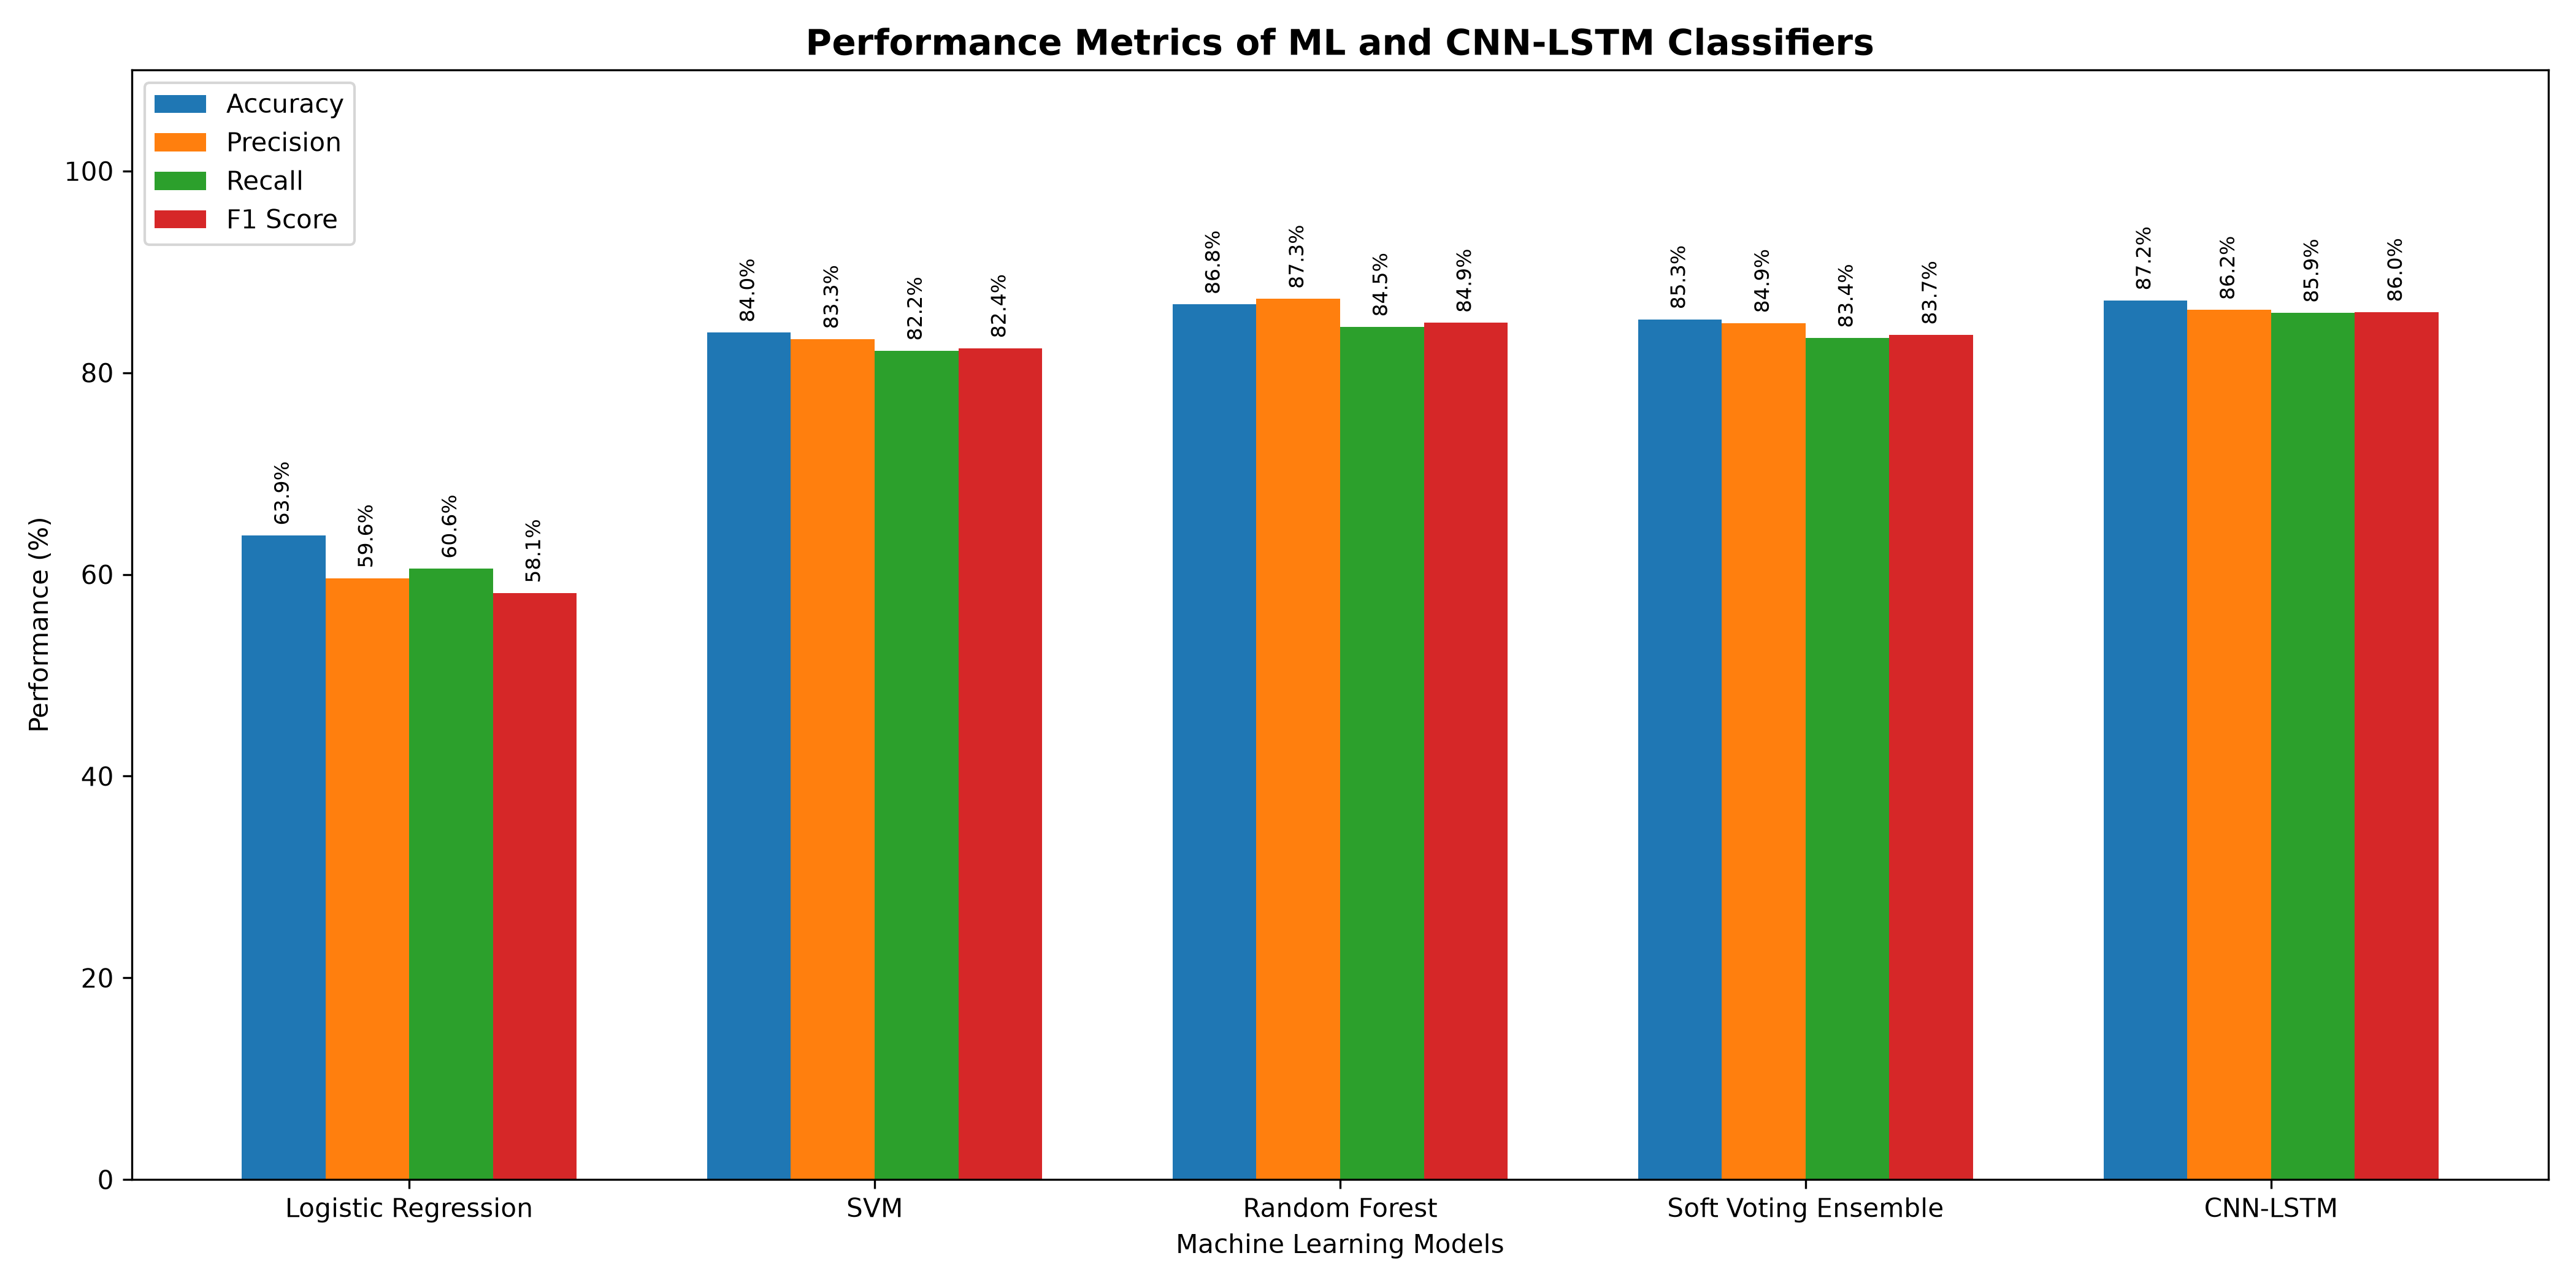

Grafik performance disimpan:
C:\Users\rizki\OneDrive\Documents\SEMESTER 6 (Magang Studi Independen)\PROJEK\OTDR\reports\figures\performance_comparison_all_models.png


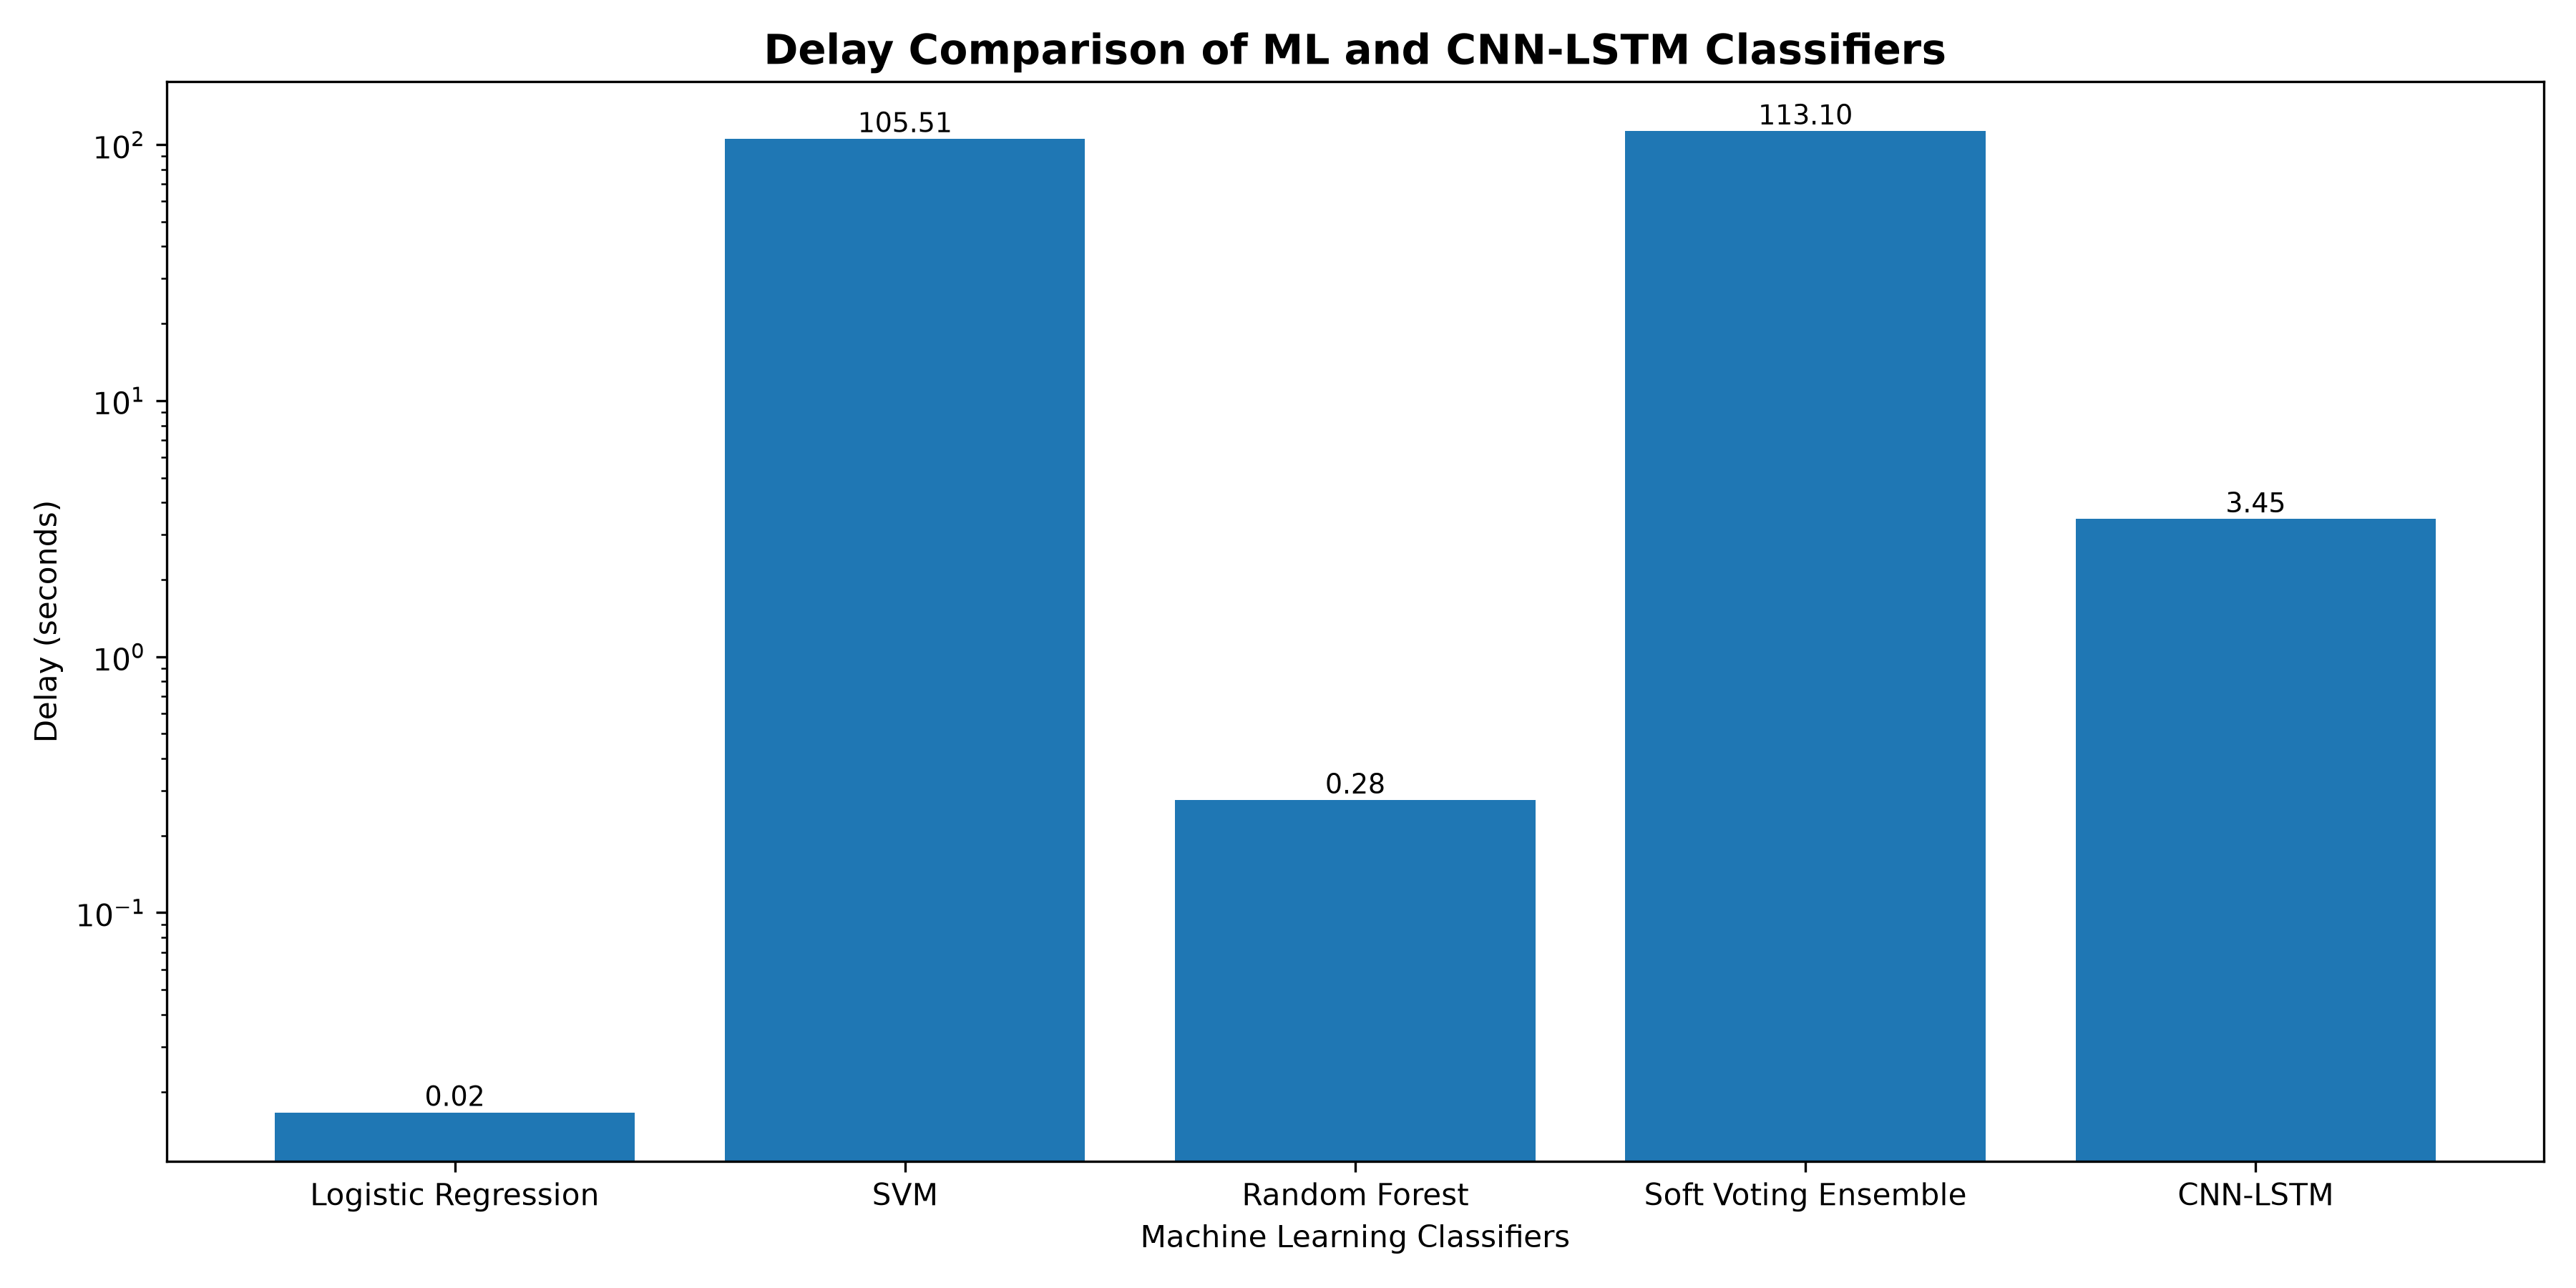

Grafik delay disimpan:
C:\Users\rizki\OneDrive\Documents\SEMESTER 6 (Magang Studi Independen)\PROJEK\OTDR\reports\figures\delay_comparison_all_models.png


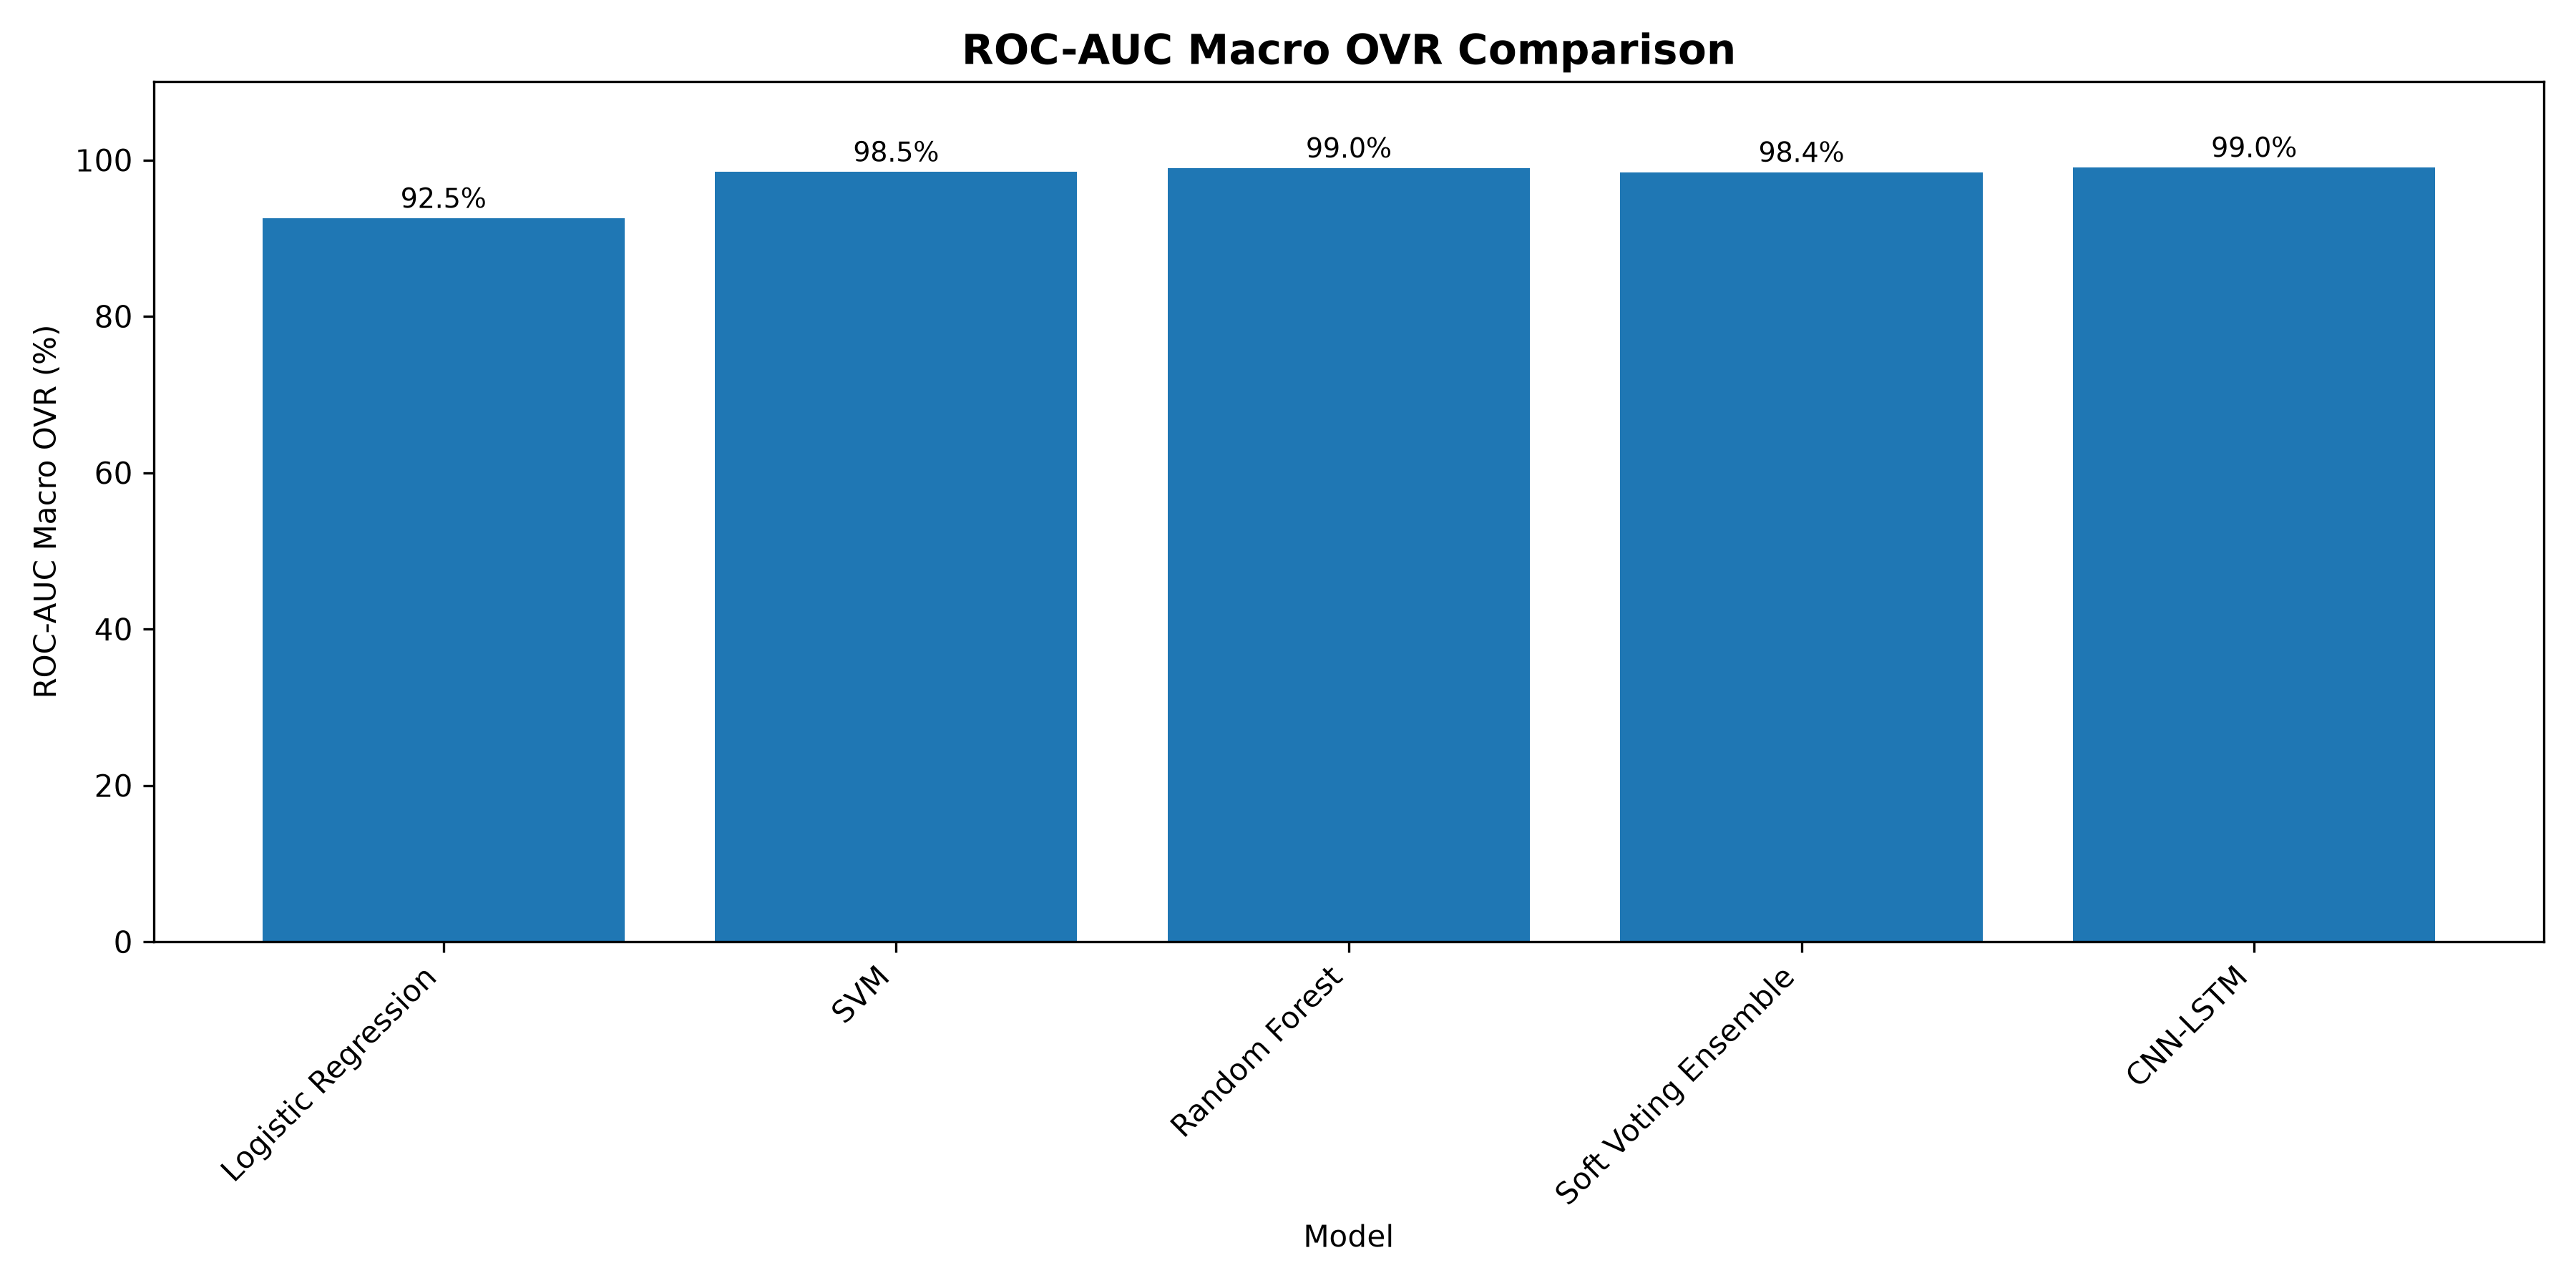

Grafik ROC-AUC disimpan:
C:\Users\rizki\OneDrive\Documents\SEMESTER 6 (Magang Studi Independen)\PROJEK\OTDR\reports\figures\roc_auc_comparison_all_models.png

Model terbaik berdasarkan F1-score:
model_name           CNN-LSTM
accuracy             0.871607
f1_macro             0.860103
roc_auc_macro_ovr    0.990374
testing_delay_sec      3.4532
Name: 4, dtype: object

Model tercepat berdasarkan testing delay:
model_name           Logistic Regression
accuracy                        0.638658
f1_macro                        0.581389
roc_auc_macro_ovr                0.92539
testing_delay_sec               0.016595
Name: 0, dtype: object

Selesai.


In [1]:

"""
04_plot_model_comparison_from_custom_paths.py

Membuat grafik perbandingan performa dan delay seperti artikel dari dua file CSV:

1. Machine Learning:
C:\\Users\\rizki\\OneDrive\\Documents\\SEMESTER 6 (Magang Studi Independen)\\PROJEK\\OTDR\\machine learning\\reports\\ml_model_comparison_rf_svm_lr_voting.csv

2. CNN-LSTM:
C:\\Users\\rizki\\OneDrive\\Documents\\SEMESTER 6 (Magang Studi Independen)\\PROJEK\\OTDR\\reports\\cnn_lstm_single_input_evaluation.csv

Cara menjalankan:
python 04_plot_model_comparison_from_custom_paths.py
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. Path file input
# ============================================================

ML_FILE = r"C:\Users\rizki\OneDrive\Documents\SEMESTER 6 (Magang Studi Independen)\PROJEK\OTDR\machine learning\reports\ml_model_comparison_rf_svm_lr_voting.csv"

CNN_FILE = r"C:\Users\rizki\OneDrive\Documents\SEMESTER 6 (Magang Studi Independen)\PROJEK\OTDR\reports\cnn_lstm_single_input_evaluation.csv"


# ============================================================
# 2. Folder output
# ============================================================

BASE_OUTPUT_DIR = r"C:\Users\rizki\OneDrive\Documents\SEMESTER 6 (Magang Studi Independen)\PROJEK\OTDR\reports"
FIGURE_DIR = os.path.join(BASE_OUTPUT_DIR, "figures")

os.makedirs(BASE_OUTPUT_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)


# ============================================================
# 3. Cek file
# ============================================================

if not os.path.exists(ML_FILE):
    raise FileNotFoundError(f"File ML tidak ditemukan:\n{ML_FILE}")

if not os.path.exists(CNN_FILE):
    raise FileNotFoundError(f"File CNN-LSTM tidak ditemukan:\n{CNN_FILE}")

print("File ML ditemukan:")
print(ML_FILE)

print("\nFile CNN-LSTM ditemukan:")
print(CNN_FILE)


# ============================================================
# 4. Load file
# ============================================================

ml_df = pd.read_csv(ML_FILE)
cnn_df = pd.read_csv(CNN_FILE)

print("\nKolom file ML:")
print(ml_df.columns.tolist())

print("\nKolom file CNN-LSTM:")
print(cnn_df.columns.tolist())


# ============================================================
# 5. Standardisasi nama kolom
# ============================================================

def standardize_columns(df):
    rename_map = {
        "model": "model_name",
        "Model": "model_name",
        "Model Name": "model_name",

        "accuracy_score": "accuracy",
        "Accuracy": "accuracy",

        "Precision": "precision_macro",
        "precision": "precision_macro",
        "precision_score": "precision_macro",

        "Recall": "recall_macro",
        "recall": "recall_macro",
        "recall_score": "recall_macro",

        "F1": "f1_macro",
        "F1 Score": "f1_macro",
        "f1": "f1_macro",
        "f1_score": "f1_macro",

        "ROC-AUC": "roc_auc_macro_ovr",
        "roc_auc": "roc_auc_macro_ovr",
        "roc_auc_macro": "roc_auc_macro_ovr",

        "training_time": "training_time_sec",
        "Training Time": "training_time_sec",

        "testing_time": "testing_delay_sec",
        "testing_delay": "testing_delay_sec",
        "delay": "testing_delay_sec",
        "Delay": "testing_delay_sec",
        "Testing Delay": "testing_delay_sec",
    }

    df = df.copy()
    df = df.rename(columns={col: rename_map.get(col, col) for col in df.columns})
    return df


ml_df = standardize_columns(ml_df)
cnn_df = standardize_columns(cnn_df)


# ============================================================
# 6. Validasi kolom wajib
# ============================================================

required_cols = [
    "accuracy",
    "precision_macro",
    "recall_macro",
    "f1_macro",
    "testing_delay_sec"
]


def ensure_columns(df, source_name):
    if "model_name" not in df.columns:
        if source_name == "CNN-LSTM":
            df["model_name"] = "CNN-LSTM"
        else:
            raise ValueError(
                f"Kolom model_name tidak ditemukan pada {source_name}.\n"
                f"Kolom tersedia: {df.columns.tolist()}"
            )

    missing = [col for col in required_cols if col not in df.columns]
    if missing:
        raise ValueError(
            f"Kolom wajib berikut tidak ditemukan pada {source_name}: {missing}\n"
            f"Kolom tersedia: {df.columns.tolist()}"
        )

    if "roc_auc_macro_ovr" not in df.columns:
        df["roc_auc_macro_ovr"] = np.nan

    if "training_time_sec" not in df.columns:
        df["training_time_sec"] = np.nan

    return df


ml_df = ensure_columns(ml_df, "ML")
cnn_df = ensure_columns(cnn_df, "CNN-LSTM")


# ============================================================
# 7. Rapikan nama model
# ============================================================

def clean_model_name(name):
    name = str(name).strip()

    mapping = {
        "rf": "Random Forest",
        "random_forest": "Random Forest",
        "RandomForest": "Random Forest",
        "Random Forest": "Random Forest",

        "svm": "SVM",
        "SVC": "SVM",
        "Support Vector Machine": "SVM",

        "lr": "Logistic Regression",
        "logistic_regression": "Logistic Regression",
        "Logistic Regression": "Logistic Regression",

        "soft_voting": "Soft Voting Ensemble",
        "soft_voting_ensemble": "Soft Voting Ensemble",
        "Soft Voting": "Soft Voting Ensemble",
        "Soft Voting Ensemble": "Soft Voting Ensemble",

        "cnn_lstm": "CNN-LSTM",
        "CNN LSTM": "CNN-LSTM",
        "CNN-LSTM": "CNN-LSTM",
        "CNN_LSTM": "CNN-LSTM",
        "CNN-LSTM Single Input": "CNN-LSTM",
        "CNN_LSTM_SINGLE_INPUT": "CNN-LSTM",
    }

    return mapping.get(name, name)


ml_df["model_name"] = ml_df["model_name"].apply(clean_model_name)
cnn_df["model_name"] = "CNN-LSTM"


# ============================================================
# 8. Gabungkan hasil ML dan CNN-LSTM
# ============================================================

selected_cols = [
    "model_name",
    "accuracy",
    "precision_macro",
    "recall_macro",
    "f1_macro",
    "roc_auc_macro_ovr",
    "training_time_sec",
    "testing_delay_sec"
]

comparison_df = pd.concat(
    [ml_df[selected_cols], cnn_df[selected_cols]],
    ignore_index=True
)

comparison_df = comparison_df.drop_duplicates(subset=["model_name"], keep="last")

model_order = [
    "Logistic Regression",
    "SVM",
    "Random Forest",
    "Soft Voting Ensemble",
    "CNN-LSTM"
]

comparison_df["model_order"] = comparison_df["model_name"].apply(
    lambda x: model_order.index(x) if x in model_order else 999
)

comparison_df = (
    comparison_df
    .sort_values("model_order")
    .drop(columns=["model_order"])
    .reset_index(drop=True)
)

print("\nTabel gabungan final:")
print(comparison_df)

FINAL_CSV = os.path.join(BASE_OUTPUT_DIR, "final_model_comparison_all_models.csv")
comparison_df.to_csv(FINAL_CSV, index=False)

print("\nTabel final disimpan:")
print(FINAL_CSV)


# ============================================================
# 9. Grafik performance seperti artikel
# ============================================================

def plot_performance_comparison(df):
    metrics = {
        "accuracy": "Accuracy",
        "precision_macro": "Precision",
        "recall_macro": "Recall",
        "f1_macro": "F1 Score"
    }

    x = np.arange(len(df["model_name"]))
    width = 0.18

    plt.figure(figsize=(14, 7))

    for i, (col, label) in enumerate(metrics.items()):
        values = df[col].astype(float).values * 100
        bars = plt.bar(x + i * width, values, width, label=label)

        for bar in bars:
            height = bar.get_height()
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                height + 1,
                f"{height:.1f}%",
                ha="center",
                va="bottom",
                fontsize=8,
                rotation=90
            )

    plt.title("Performance Metrics of ML and CNN-LSTM Classifiers", fontsize=14, fontweight="bold")
    plt.xlabel("Machine Learning Models")
    plt.ylabel("Performance (%)")
    plt.xticks(x + width * 1.5, df["model_name"], rotation=0, ha="center")
    plt.ylim(0, 110)
    plt.legend()
    plt.tight_layout()

    output_path = os.path.join(FIGURE_DIR, "performance_comparison_all_models.png")
    plt.savefig(output_path, dpi=300)
    plt.show()

    print("Grafik performance disimpan:")
    print(output_path)


# ============================================================
# 10. Grafik delay seperti artikel
# ============================================================

def plot_delay_comparison(df):
    delay_df = df[["model_name", "testing_delay_sec"]].copy()
    delay_df["testing_delay_sec"] = delay_df["testing_delay_sec"].astype(float)

    plt.figure(figsize=(12, 6))

    bars = plt.bar(delay_df["model_name"], delay_df["testing_delay_sec"])

    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:.2f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

    plt.yscale("log")
    plt.title("Delay Comparison of ML and CNN-LSTM Classifiers", fontsize=14, fontweight="bold")
    plt.xlabel("Machine Learning Classifiers")
    plt.ylabel("Delay (seconds)")
    plt.xticks(rotation=0, ha="center")
    plt.tight_layout()

    output_path = os.path.join(FIGURE_DIR, "delay_comparison_all_models.png")
    plt.savefig(output_path, dpi=300)
    plt.show()

    print("Grafik delay disimpan:")
    print(output_path)


# ============================================================
# 11. Grafik ROC-AUC tambahan
# ============================================================

def plot_roc_auc_comparison(df):
    roc_df = df[["model_name", "roc_auc_macro_ovr"]].dropna().copy()

    if roc_df.empty:
        print("ROC-AUC kosong. Grafik ROC-AUC dilewati.")
        return

    roc_df["roc_auc_macro_ovr"] = roc_df["roc_auc_macro_ovr"].astype(float)

    plt.figure(figsize=(12, 6))

    bars = plt.bar(roc_df["model_name"], roc_df["roc_auc_macro_ovr"] * 100)

    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.5,
            f"{height:.1f}%",
            ha="center",
            va="bottom",
            fontsize=9
        )

    plt.title("ROC-AUC Macro OVR Comparison", fontsize=14, fontweight="bold")
    plt.xlabel("Model")
    plt.ylabel("ROC-AUC Macro OVR (%)")
    plt.xticks(rotation=45, ha="right")
    plt.ylim(0, 110)
    plt.tight_layout()

    output_path = os.path.join(FIGURE_DIR, "roc_auc_comparison_all_models.png")
    plt.savefig(output_path, dpi=300)
    plt.show()

    print("Grafik ROC-AUC disimpan:")
    print(output_path)


# ============================================================
# 12. Jalankan semua grafik
# ============================================================

plot_performance_comparison(comparison_df)
plot_delay_comparison(comparison_df)
plot_roc_auc_comparison(comparison_df)


# ============================================================
# 13. Ringkasan model terbaik
# ============================================================

best_by_f1 = comparison_df.sort_values("f1_macro", ascending=False).iloc[0]
best_by_delay = comparison_df.sort_values("testing_delay_sec", ascending=True).iloc[0]

print("\nModel terbaik berdasarkan F1-score:")
print(best_by_f1[["model_name", "accuracy", "f1_macro", "roc_auc_macro_ovr", "testing_delay_sec"]])

print("\nModel tercepat berdasarkan testing delay:")
print(best_by_delay[["model_name", "accuracy", "f1_macro", "roc_auc_macro_ovr", "testing_delay_sec"]])

print("\nSelesai.")
